In [34]:
subject = "sub-097"

from pathlib import Path

from nilearn.image import mean_img
from nilearn.plotting import plot_img, show


project_dir = Path(r"C:\ManzaRotation")

raw_dir = project_dir / "Raw"
derivatives_dir = project_dir / "Derivatives"
analysis_dir = project_dir / "Analysis"

subject_deriv_dir = derivatives_dir / subject
subject_raw_dir = raw_dir / subject

func_deriv_dir = subject_deriv_dir / "func"
anat_deriv_dir = subject_deriv_dir / "anat"

basic_glm_dir = analysis_dir / "outputs" / subject / "basic_glm"
figures_dir = basic_glm_dir / "figures"

In [35]:
modulate1_path = func_deriv_dir/f"{subject}_task-modulate1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz"
modulate2_path = func_deriv_dir/f"{subject}_task-modulate2_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz"


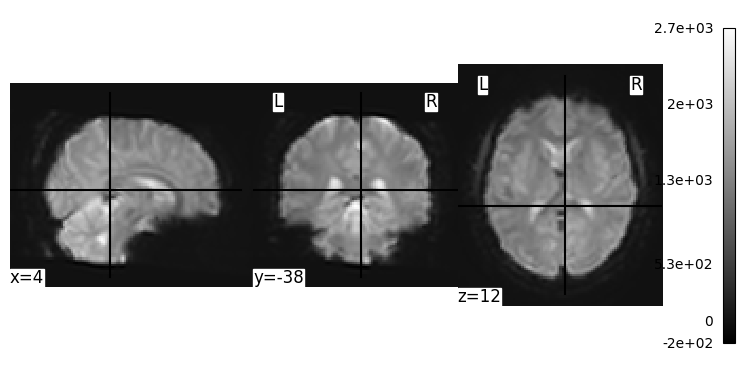

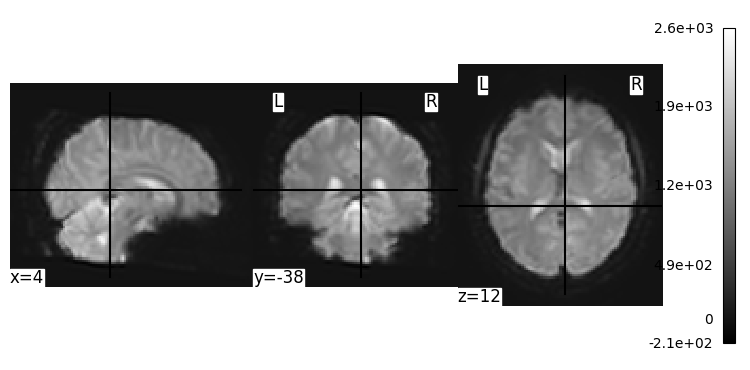

In [36]:
mean_func_1 = mean_img(modulate1_path)
mean_func_2 = mean_img(modulate2_path)
plot_img(mean_func_1)
plot_img(mean_func_2)


In [37]:
anat_path = anat_deriv_dir / f"{subject}_space-MNI152NLin2009cAsym_res-2_desc-preproc_T1w.nii.gz"
print(anat_path)
print(anat_path.exists())

C:\ManzaRotation\Derivatives\sub-097\anat\sub-097_space-MNI152NLin2009cAsym_res-2_desc-preproc_T1w.nii.gz
True


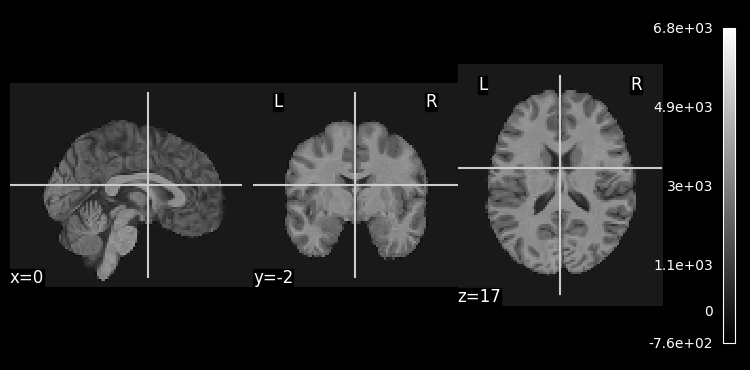

In [38]:
from nilearn.plotting import plot_anat
plot_anat(anat_path)

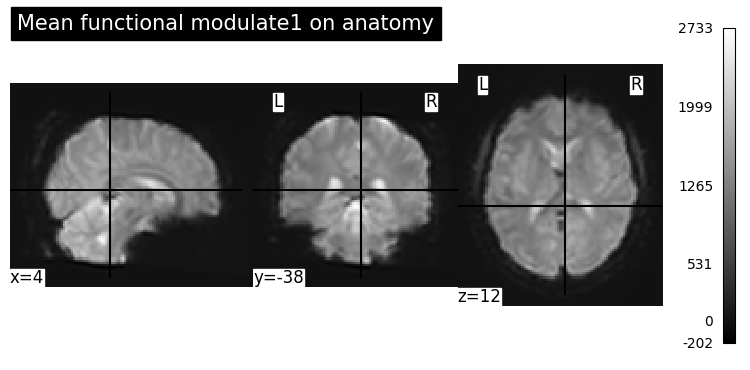

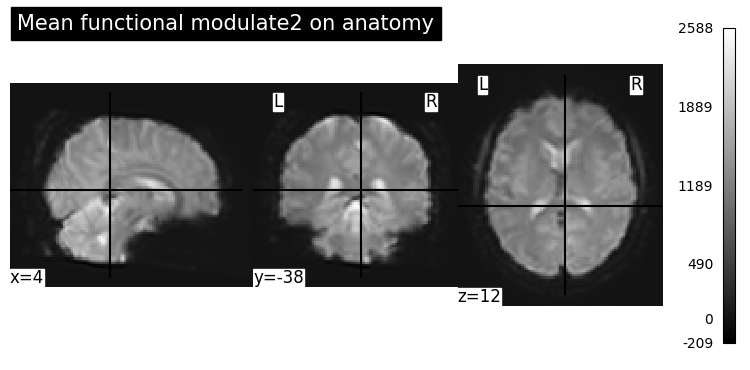

Mask1 exists: True
Mask2 exists: True


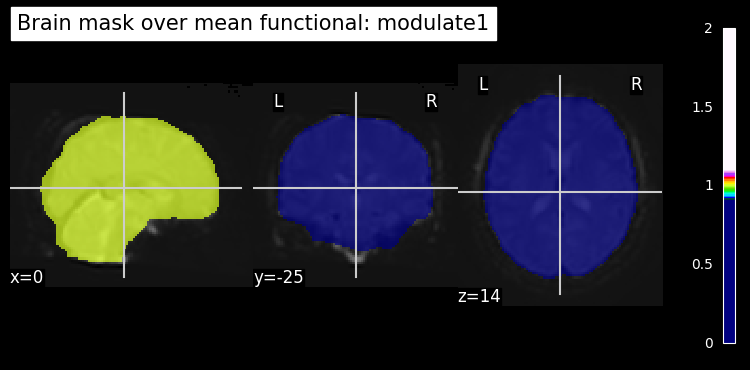

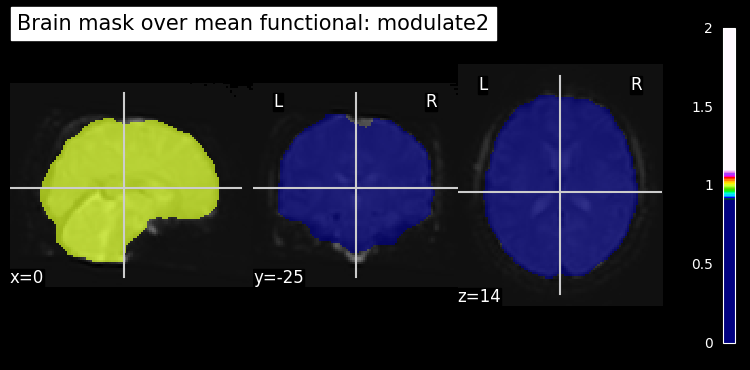

In [40]:
# ----------------------------
# Functional-anatomical alignment check
# ----------------------------
from nilearn.plotting import plot_img, plot_anat, plot_roi, show

from nilearn.plotting import plot_roi

plot_img(
    mean_func_1,
    bg_img=anat_path,
    title="Mean functional modulate1 on anatomy",
    cbar_tick_format="%i",
)
show()

plot_img(
    mean_func_2,
    bg_img=anat_path,
    title="Mean functional modulate2 on anatomy",
    cbar_tick_format="%i",
)
show()


# ----------------------------
# Brain masks
# ----------------------------

mask1_path = func_deriv_dir / f"{subject}_task-modulate1_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz"
mask2_path = func_deriv_dir / f"{subject}_task-modulate2_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz"

print("Mask1 exists:", mask1_path.exists())
print("Mask2 exists:", mask2_path.exists())

plot_roi(
    mask1_path,
    bg_img=mean_func_1,
    title="Brain mask over mean functional: modulate1",
)
show()

plot_roi(
    mask2_path,
    bg_img=mean_func_2,
    title="Brain mask over mean functional: modulate2",
)
show()

In [41]:
# Save inspection figures into a separate folder under the subject basic_glm outputs.
inspection_dir = figures_dir / "inspection"
inspection_dir.mkdir(parents=True, exist_ok=True)

plot_img(
    mean_func_1,
    bg_img=anat_path,
    title="Mean functional modulate1 on anatomy",
    cbar_tick_format="%i",
    output_file=inspection_dir / "mean_func_modulate1_on_anatomy.png",
)

plot_img(
    mean_func_2,
    bg_img=anat_path,
    title="Mean functional modulate2 on anatomy",
    cbar_tick_format="%i",
    output_file=inspection_dir / "mean_func_modulate2_on_anatomy.png",
)

plot_roi(
    mask1_path,
    bg_img=mean_func_1,
    title="Brain mask over mean functional: modulate1",
    output_file=inspection_dir / "brain_mask_modulate1.png",
)

plot_roi(
    mask2_path,
    bg_img=mean_func_2,
    title="Brain mask over mean functional: modulate2",
    output_file=inspection_dir / "brain_mask_modulate2.png",
)

print(f"Saved inspection figures to: {inspection_dir}")

Saved inspection figures to: C:\ManzaRotation\Analysis\outputs\sub-097\basic_glm\figures\inspection
